# Getriebe-Analyse Task 2
In diesem Notebook werden die Signaldaten aus Task 2 geladen und analysiert.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from dataframe_manager import DataFrameManager

# Pfad zum Datenordner in Task 2
data_path = '../data'

# Initialisierung des Managers und Laden der Signale
manager = DataFrameManager(data_dir=data_path)
manager.load_signals()

# Dataframe abrufen und erste Zeilen anzeigen
df = manager.get_dataframe()
print(f"Erfolgreich {len(df)} Signale geladen.")
df.head()

Erfolgreich 440 Signale geladen.


,fn,sig,fs,spec,pos,mID,time,rID,sID
0,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1...,"[0.00048828125, 0.00244140625, 0.0029296875, 0...",1041666,Z01,Pos00,0000,1307031427,00000,Ch1
1,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch2...,"[0.001953125, 0.0, 0.00146484375, 0.001953125,...",1041666,Z01,Pos00,0000,1307031427,00000,Ch2
2,Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch1...,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...",1041666,Z01,Pos00,0000,1307031427,00001,Ch1
3,Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch2...,"[-0.00048828125, 0.0009765625, 0.0, -0.0009765...",1041666,Z01,Pos00,0000,1307031427,00001,Ch2
4,Z01_Pos00_RC2_75k_0001_1312091511_00000_14_Ch1...,"[0.00048828125, 0.00146484375, 0.00048828125, ...",1041666,Z01,Pos00,0001,1312091511,00000,Ch1


### 1. rID Prüfung (Durchläufe)
Hier prüfen wir für jede Messung (Zahnrad, Position, mID, Sensor), ob die zwei Durchläufe (rID 00000 und 00001) konsistent sind. Abweichungen von mehr als 5% im RMS-Wert werden ausgegeben.

In [ ]:
def check_rid_deviations(df, threshold=0.05):
    print(f"Prüfe rID Abweichungen (Threshold: {threshold*100}%)...")
    # Gruppieren nach Merkmalen, die eine Messreihe definieren
    groups = df.groupby(['spec', 'pos', 'mID', 'sID'])
    
    found_issue = False
    for name, group in groups:
        if len(group) >= 2:
            # Sortieren nach rID um konsistent zu vergleichen
            group = group.sort_values('rID')
            sigs = group['sig'].values
            
            # RMS berechnen
            rms_values = [np.sqrt(np.mean(s**2)) for s in sigs[:2]]
            
            rms1, rms2 = rms_values[0], rms_values[1]
            if rms1 > 0:
                deviation = abs(rms1 - rms2) / rms1
                if deviation > threshold:
                    print(f"Abweichung > {threshold*100}% bei setup {name}: rID_0={rms1:.4f}, rID_1={rms2:.4f} (Dev: {deviation:.2%})")
                    found_issue = True
    
    if not found_issue:
        print("Keine signifikanten Abweichungen bei den Durchläufen (rID) gefunden.")

check_rid_deviations(df)

### 2. mID Prüfung (Messungs-IDs)
Hier prüfen wir, ob verschiedene Messungen (mID) für denselben Aufbau (Zahnrad, Position, Sensor) konsistent sind. Wir mitteln zuerst die Durchläufe (rIDs) pro mID und vergleichen dann die mIDs.

In [ ]:
def check_mid_deviations(df, threshold=0.05):
    print(f"Prüfe mID Abweichungen (Threshold: {threshold*100}%)...")
    
    # Erst RMS für alle Signale berechnen
    df_rms = df.copy()
    df_rms['rms'] = df_rms['sig'].apply(lambda x: np.sqrt(np.mean(x**2)))
    
    # Durchschnittliche RMS pro mID berechnen (über alle rIDs)
    mid_averages = df_rms.groupby(['spec', 'pos', 'sID', 'mID'])['rms'].mean().reset_index()
    
    # Gruppieren nach Setup, um mIDs zu vergleichen
    setup_groups = mid_averages.groupby(['spec', 'pos', 'sID'])
    
    found_issue = False
    for name, group in setup_groups:
        if len(group) >= 2:
            group = group.sort_values('mID')
            rms_vals = group['rms'].values
            
            # Vergleich der ersten beiden mIDs
            rms1, rms2 = rms_vals[0], rms_vals[1]
            if rms1 > 0:
                deviation = abs(rms1 - rms2) / rms1
                if deviation > threshold:
                    mIDs = group['mID'].values
                    print(f"Abweichung > {threshold*100}% bei setup {name}: mID_{mIDs[0]}={rms1:.4f}, mID_{mIDs[1]}={rms2:.4f} (Dev: {deviation:.2%})")
                    found_issue = True
                    
    if not found_issue:
        print("Keine signifikanten Abweichungen zwischen den Messungen (mID) gefunden.")

check_mid_deviations(df)

### 3. STFT Analyse und 2D Visualisierung
Diese Funktion berechnet die STFT für die Zahnräder Z01 bis Z05 an einer wählbaren Position und stellt das Spektrogramm sowie Magnitude und Amplitude dar.

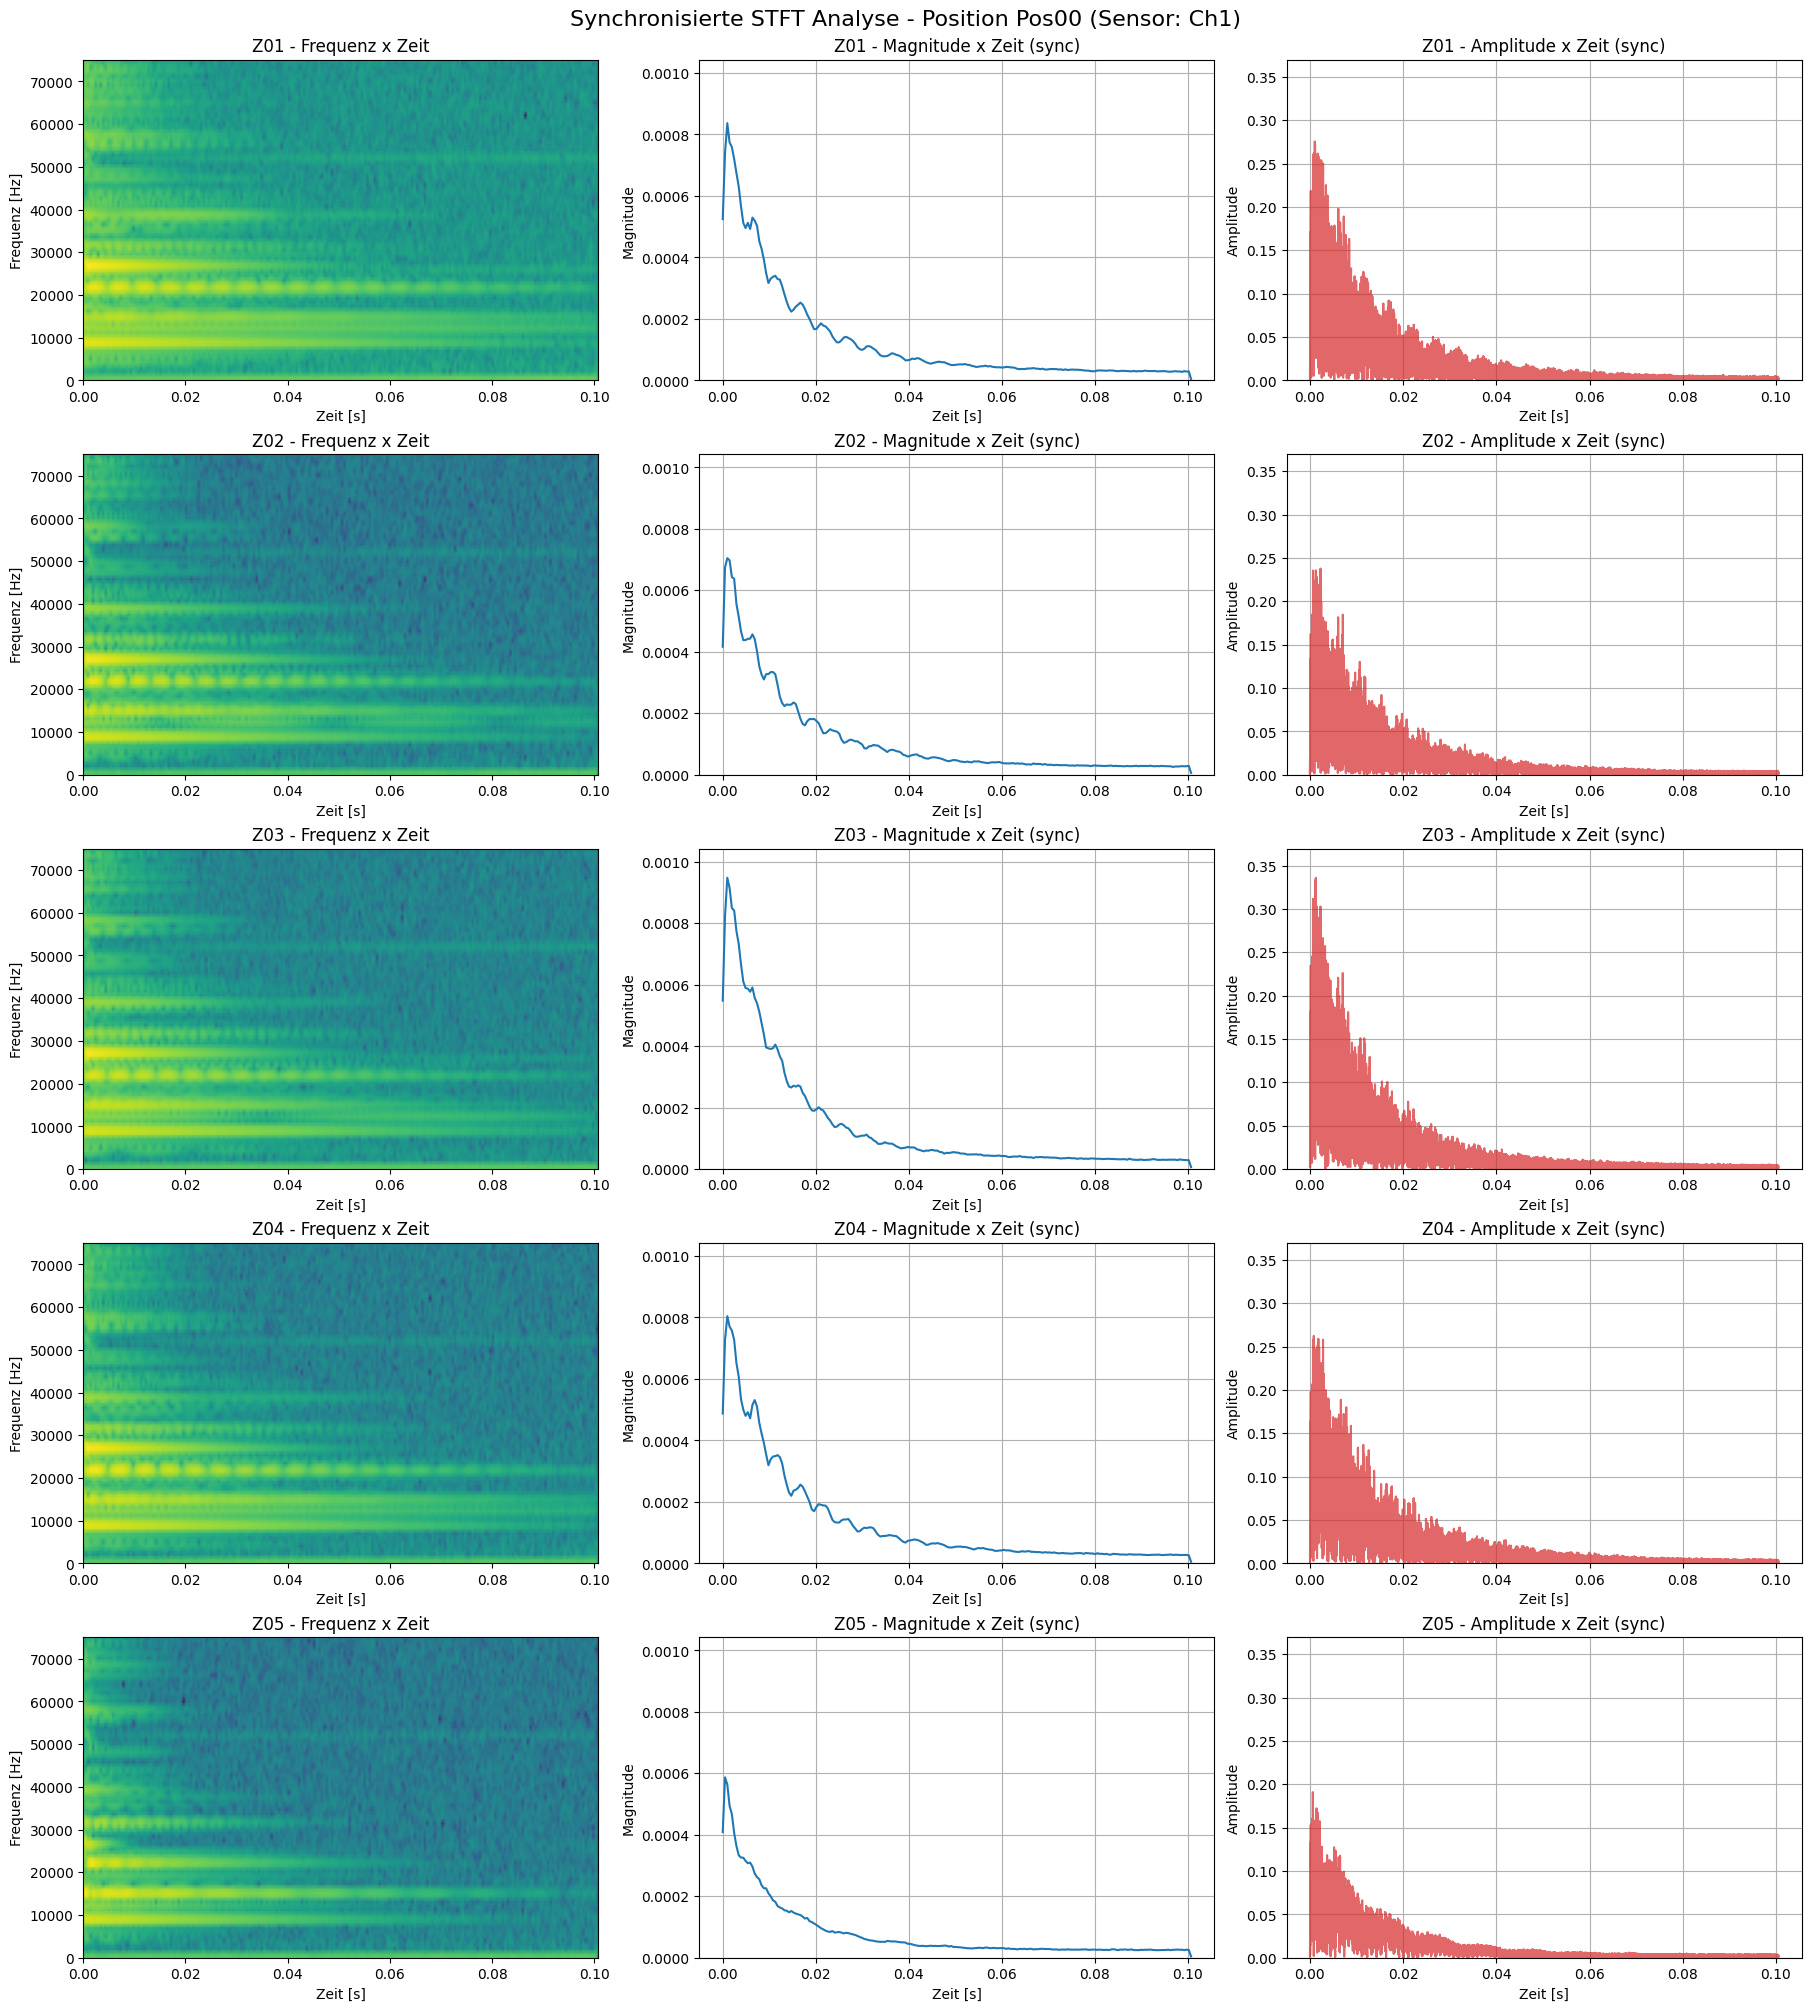

In [2]:
def calculate_stft(sig, fs, nperseg=256, noverlap=None, window='hann'):
    """Berechnet die STFT (wie in Task 1)."""
    f, t, Zxx = signal.stft(sig, fs, window=window, nperseg=nperseg, noverlap=noverlap)
    return f, t, Zxx

def plot_gear_analysis(df, pos='Pos00', nperseg=1024, noverlap=512, sensor='Ch1'):
    """
    Stellt drei 2D Diagramme für Z01-Z05 untereinander dar.
    Skalen (Y-Achse) sind über alle Zahnräder hinweg synchronisiert.
    """
    gears = ['Z01', 'Z02', 'Z03', 'Z04', 'Z05']
    
    # Vorfiltern für Position und Sensor
    plot_df = df[(df['pos'] == pos) & (df['sID'] == sensor)]
    
    if plot_df.empty:
        print(f"Keine Daten für Position {pos} und Sensor {sensor} gefunden.")
        return

    # 1. Durchgang: Max-Werte für Skalierung ermitteln
    global_max_mag = 0
    global_max_amp = 0
    analysis_data = {}
    
    for gear in gears:
        gear_data = plot_df[plot_df['spec'] == gear]
        if not gear_data.empty:
            sample = gear_data.iloc[0]
            sig = sample['sig']
            fs = sample['fs']
            
            # STFT & Magnitude
            f, t, Zxx = calculate_stft(sig, fs, nperseg=nperseg, noverlap=noverlap)
            mag = np.abs(Zxx)
            mean_mag = np.mean(mag, axis=0)
            global_max_mag = max(global_max_mag, np.max(mean_mag))
            
            # Amplitude (Envelope)
            analytic_signal = signal.hilbert(sig)
            env = np.abs(analytic_signal)
            global_max_amp = max(global_max_amp, np.max(env))
            
            # Daten für Plotting speichern
            analysis_data[gear] = {
                'f': f, 't': t, 'mag': mag, 'mean_mag': mean_mag, 
                'env': env, 'sig': sig, 'fs': fs
            }

    # 2. Durchgang: Plotten mit einheitlichen Skalen
    fig, axes = plt.subplots(len(gears), 3, figsize=(18, 4 * len(gears)), constrained_layout=True)
    fig.suptitle(f"Synchronisierte STFT Analyse - Position {pos} (Sensor: {sensor})", fontsize=16)

    for i, gear in enumerate(gears):
        if gear not in analysis_data:
            for j in range(3):
                axes[i, j].text(0.5, 0.5, f"Keine Daten für {gear}", ha='center')
            continue
            
        data = analysis_data[gear]
        
        # 1. Diagramm: Frequenz x Zeit
        ax_freq = axes[i, 0]
        ax_freq.pcolormesh(data['t'], data['f'], 20 * np.log10(data['mag'] + 1e-10), shading='gouraud', cmap='viridis')
        ax_freq.set_ylim(0, 75000)
        ax_freq.set_title(f"{gear} - Frequenz x Zeit")
        ax_freq.set_ylabel("Frequenz [Hz]")
        ax_freq.set_xlabel("Zeit [s]")
        
        # 2. Diagramm: Magnitude x Zeit (Synchronisierte Y-Achse)
        ax_mag = axes[i, 1]
        ax_mag.plot(data['t'], data['mean_mag'], color='tab:blue')
        ax_mag.set_ylim(0, global_max_mag * 1.1)
        ax_mag.set_title(f"{gear} - Magnitude x Zeit (sync)")
        ax_mag.set_ylabel("Magnitude")
        ax_mag.set_xlabel("Zeit [s]")
        ax_mag.grid(True)
        
        # 3. Diagramm: Amplitude x Zeit (Synchronisierte Y-Achse)
        ax_amp = axes[i, 2]
        t_sig = np.linspace(0, len(data['sig'])/data['fs'], len(data['sig']))
        ax_amp.plot(t_sig, data['env'], color='tab:red', alpha=0.7)
        ax_amp.set_ylim(0, global_max_amp * 1.1)
        ax_amp.set_title(f"{gear} - Amplitude x Zeit (sync)")
        ax_amp.set_ylabel("Amplitude")
        ax_amp.set_xlabel("Zeit [s]")
        ax_amp.grid(True)

    plt.show()

# Beispielaufruf
plot_gear_analysis(df, pos='Pos00', nperseg=1024, noverlap=512)